# Chocolate sales — exploratory data analysis

Imports, dataset download, data-quality checks (sales/products/stores/customers only), merged transaction table, univariate plots, correlation matrix (Pearson + Spearman), scatter plots for pairs with **|r| > 0.7**, and time/categorical views from `sales.order_date` (no `calendar.csv`).

In [38]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

sns.set_theme(style="whitegrid")

# Download latest version
path = kagglehub.dataset_download("ssssws/chocolate-sales-dataset-2023-2024")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Yonatan\.cache\kagglehub\datasets\ssssws\chocolate-sales-dataset-2023-2024\versions\2


## Load CSV files

All tables live under the path returned by `kagglehub`.

In [39]:
DATA_DIR = Path(path)
stems = ("sales", "products", "stores", "customers")
files = {s: DATA_DIR / f"{s}.csv" for s in stems}

sales = pd.read_csv(files["sales"])
products = pd.read_csv(files["products"])
stores = pd.read_csv(files["stores"])
customers = pd.read_csv(files["customers"])

tables = {"sales": sales, "products": products, "stores": stores, "customers": customers}


## 0. Data quality (before main EDA)

Per-table: shape, duplicate rows, missing values, dtypes, and quick validity rules where applicable.

In [40]:
def report_quality(name: str, df: pd.DataFrame) -> None:
    print(f"=== {name} ===")
    print(f"shape: {df.shape[0]:,} rows × {df.shape[1]} cols")
    dup = df.duplicated().sum()
    print(f"duplicate rows: {dup:,}")
    na = df.isna()
    total_na = int(na.sum().sum())
    if total_na == 0:
        print("missing values: none")
    else:
        print("missing values (count / %):")
        miss = na.mean() * 100
        print(miss[miss > 0].sort_values(ascending=False).to_string())
    print("dtypes:\n", df.dtypes.to_string())
    print()


for label, frame in tables.items():
    report_quality(label, frame)

# Transaction-level sanity checks on sales
s = sales
valid_qty = (s["quantity"] >= 0).all()
valid_money = (s[["unit_price", "revenue", "cost", "profit"]] >= 0).all().all()
disc = (s["discount"] >= 0) & (s["discount"] <= 1)
print("sales validity: quantity >= 0:", valid_qty)
print("sales validity: money cols >= 0:", valid_money)
print("sales validity: discount in [0, 1]:", bool(disc.all()))

=== sales ===
shape: 1,000,000 rows × 11 cols
duplicate rows: 0
missing values: none
dtypes:
 order_id        object
order_date      object
product_id      object
store_id        object
customer_id     object
quantity         int64
unit_price     float64
discount       float64
revenue        float64
cost           float64
profit         float64

=== products ===
shape: 200 rows × 6 cols
duplicate rows: 0
missing values: none
dtypes:
 product_id       object
product_name     object
brand            object
category         object
cocoa_percent     int64
weight_g          int64

=== stores ===
shape: 100 rows × 5 cols
duplicate rows: 0
missing values: none
dtypes:
 store_id      object
store_name    object
city          object
country       object
store_type    object

=== customers ===
shape: 50,000 rows × 5 cols
duplicate rows: 0
missing values: none
dtypes:
 customer_id       object
age                int64
gender            object
loyalty_member     int64
join_date         object

sal

## Merge transactions with dimensions

Inner joins on `product_id`, `store_id`, and `customer_id`. Rows whose `product_id` is missing from `products` are dropped (documented below). `order_date` is parsed from `sales` only for time plots; `calendar.csv` is not used.

In [41]:
n_sales = len(sales)
orph_product = ~sales["product_id"].isin(products["product_id"])
orph_store = ~sales["store_id"].isin(stores["store_id"])
orph_customer = ~sales["customer_id"].isin(customers["customer_id"])
print("orphan product_id rows:", int(orph_product.sum()))
print("orphan store_id rows:", int(orph_store.sum()))
print("orphan customer_id rows:", int(orph_customer.sum()))

df = (
    sales.merge(products, on="product_id", how="inner")
    .merge(stores, on="store_id", how="inner")
    .merge(customers, on="customer_id", how="inner")
)
print(f"\nmerged rows: {len(df):,} (dropped {n_sales - len(df):,} rows without product metadata)")

df["order_date"] = pd.to_datetime(df["order_date"])

dup_merged = df.duplicated().sum()
na_merged = df.isna().sum().sum()
print(f"merged duplicate rows: {dup_merged}")
print(f"merged total NaN cells: {na_merged}")

df.head()

orphan product_id rows: 9764
orphan store_id rows: 0
orphan customer_id rows: 0

merged rows: 990,236 (dropped 9,764 rows without product metadata)
merged duplicate rows: 0
merged total NaN cells: 0


,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,...,cocoa_percent,weight_g,store_name,city,country,store_type,age,gender,loyalty_member,join_date
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,...,70,200,Chocolate Store 93,Sydney,UK,Airport,44,Male,1,2021-11-17
1,0RD00372820,2023-07-11,P0117,S042,C040749,1,12.17,0.00,12.17,7.74,...,50,50,Chocolate Store 42,Paris,USA,Online,44,Male,1,2021-11-17
2,0RD00151766,2024-03-11,P0137,S062,C040749,5,13.19,0.00,65.95,39.50,...,80,100,Chocolate Store 62,Toronto,Canada,Airport,44,Male,1,2021-11-17
3,0RD00541095,2023-07-11,P0110,S017,C040749,3,14.75,0.00,44.25,29.73,...,50,80,Chocolate Store 17,Melbourne,UK,Airport,44,Male,1,2021-11-17
4,0RD00319312,2024-04-03,P0052,S055,C040749,4,3.59,0.00,14.36,8.82,...,90,100,Chocolate Store 55,New York,France,Retail,44,Male,1,2021-11-17


## Profile (`info`, `describe`)

Use this snapshot before plotting and correlations.

In [42]:
df.info()

df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990236 entries, 0 to 990235
Data columns (total 24 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        990236 non-null  object        
 1   order_date      990236 non-null  datetime64[ns]
 2   product_id      990236 non-null  object        
 3   store_id        990236 non-null  object        
 4   customer_id     990236 non-null  object        
 5   quantity        990236 non-null  int64         
 6   unit_price      990236 non-null  float64       
 7   discount        990236 non-null  float64       
 8   revenue         990236 non-null  float64       
 9   cost            990236 non-null  float64       
 10  profit          990236 non-null  float64       
 11  product_name    990236 non-null  object        
 12  brand           990236 non-null  object        
 13  category        990236 non-null  object        
 14  cocoa_percent   990236 non-null  int

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,...,cocoa_percent,weight_g,store_name,city,country,store_type,age,gender,loyalty_member,join_date
count,990236,990236,990236,990236,990236,990236.000000,990236.000000,990236.000000,990236.000000,990236.000000,...,990236.000000,990236.000000,990236,990236,990236,990236,990236.000000,990236,990236.000000,990236
unique,990236,NaN,200,100,50000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,100,7,6,4,NaN,2,NaN,1827
top,0RD00000001,NaN,P0021,S013,C044952,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Chocolate Store 13,Toronto,Canada,Airport,NaN,Male,NaN,2023-09-06
freq,1,NaN,5141,10107,40,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,10107,178375,198160,296204,NaN,499412,NaN,910
mean,NaN,2023-12-31 19:24:53.593043712,NaN,NaN,NaN,2.999760,9.002360,0.056242,25.487508,15.292310,...,69.148132,107.431400,NaN,NaN,NaN,NaN,44.044334,NaN,0.501855,NaN
min,NaN,2023-01-01 00:00:00,NaN,NaN,NaN,1.000000,3.000000,0.000000,2.400000,1.200000,...,50.000000,50.000000,NaN,NaN,NaN,NaN,18.000000,NaN,0.000000,NaN
25%,NaN,2023-07-02 00:00:00,NaN,NaN,NaN,2.000000,6.000000,0.000000,12.160000,7.240000,...,50.000000,80.000000,NaN,NaN,NaN,NaN,31.000000,NaN,0.000000,NaN
50%,NaN,2024-01-01 00:00:00,NaN,NaN,NaN,3.000000,9.000000,0.000000,21.920000,13.030000,...,70.000000,100.000000,NaN,NaN,NaN,NaN,44.000000,NaN,1.000000,NaN
75%,NaN,2024-07-02 00:00:00,NaN,NaN,NaN,4.000000,12.000000,0.150000,35.880000,21.420000,...,80.000000,120.000000,NaN,NaN,NaN,NaN,57.000000,NaN,1.000000,NaN
max,NaN,2024-12-31 00:00:00,NaN,NaN,NaN,5.000000,15.000000,0.200000,75.000000,52.430000,...,90.000000,200.000000,NaN,NaN,NaN,NaN,70.000000,NaN,1.000000,NaN


## Univariate EDA

Histograms / KDE for key numeric columns and bar charts for categorical frequency (full data where feasible; a capped random sample for dense seaborn plots).

Numeric columns: ['quantity', 'unit_price', 'discount', 'revenue', 'cost', 'profit', 'cocoa_percent', 'weight_g', 'age', 'loyalty_member']


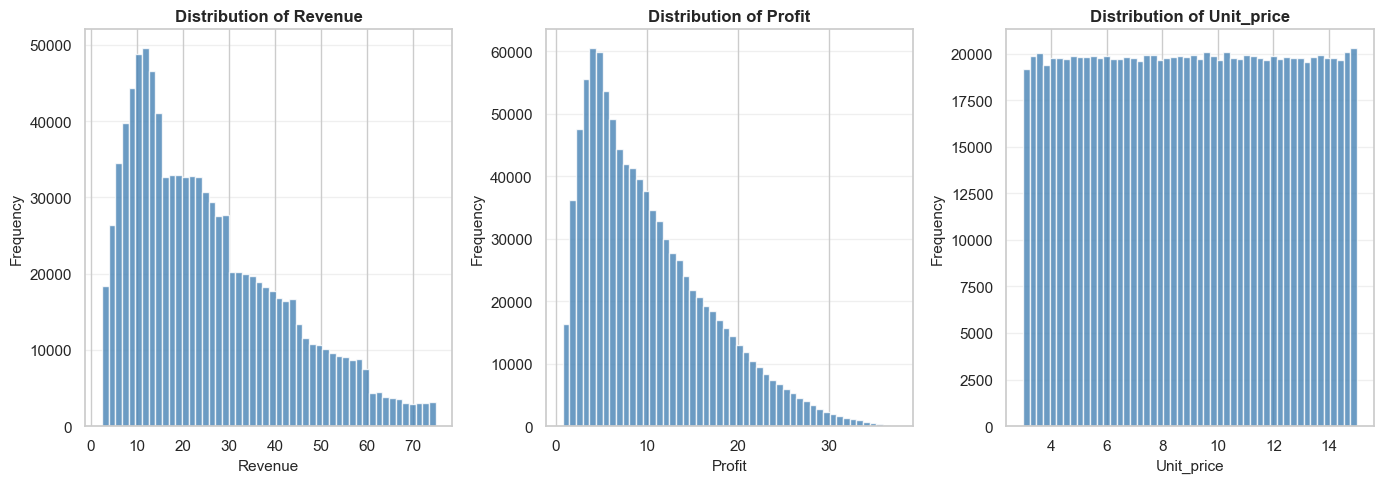

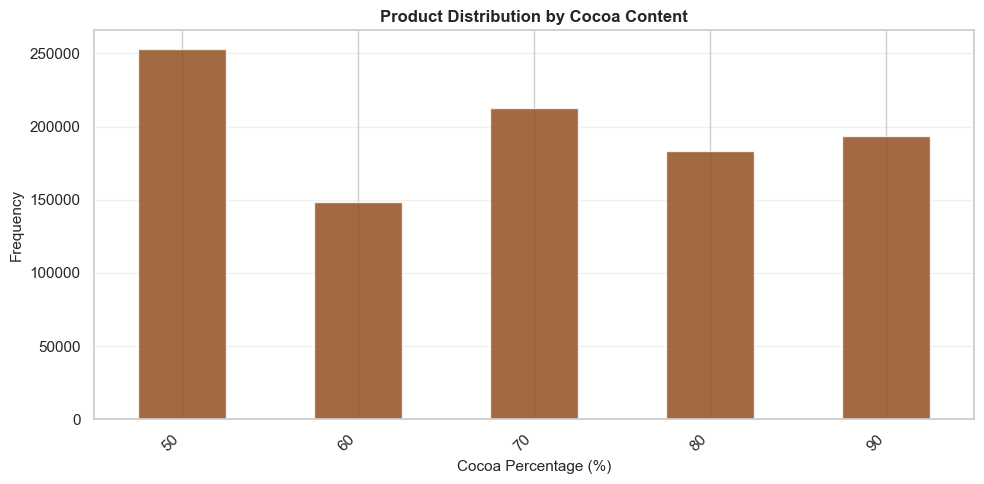

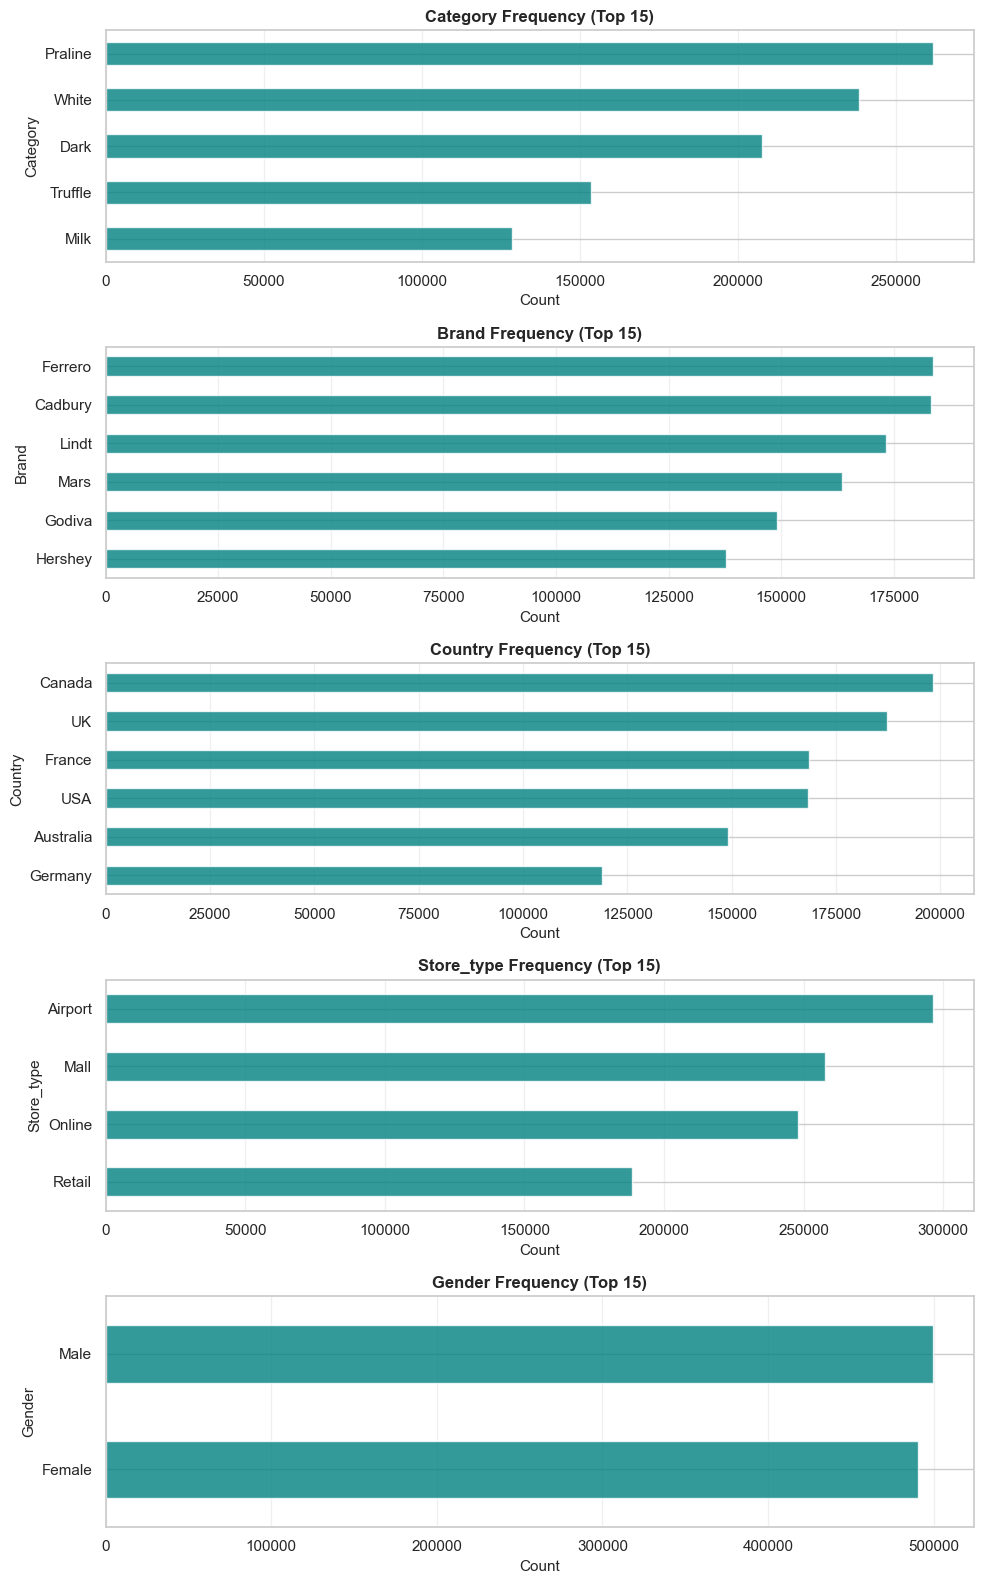

C:\Users\Yonatan\AppData\Local\Temp\ipykernel_13172\4181128928.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample_plot, x="store_type", y="revenue", ax=ax, palette="Set2", width=0.6)


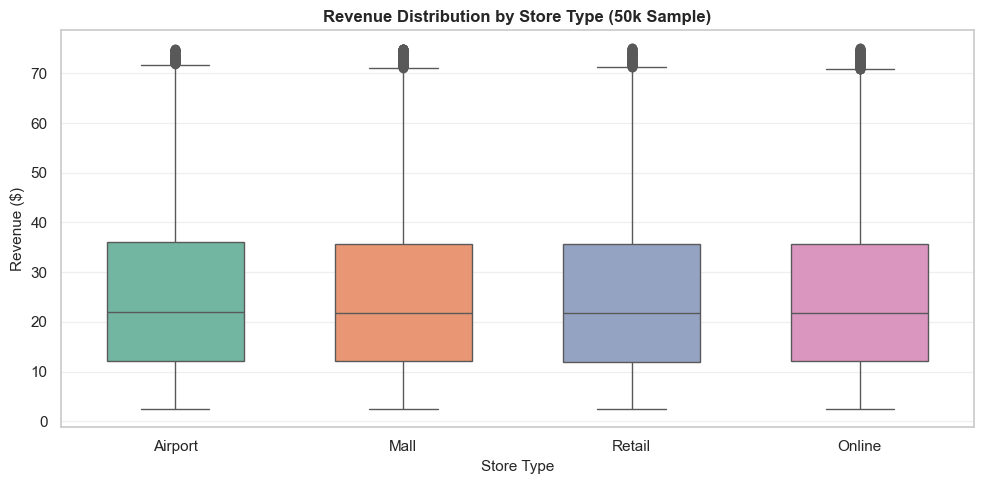

In [ ]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
print("Numeric columns:", numeric_cols)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes = axes.ravel()
for ax, col in zip(axes, ["revenue", "profit", "unit_price"]):
    df[col].hist(bins=50, ax=ax, color="steelblue", edgecolor="white", alpha=0.8)
    ax.set_title(f"Distribution of {col.capitalize()}", fontsize=12, fontweight="bold")
    ax.set_xlabel(col.capitalize(), fontsize=11)
    ax.set_ylabel("Frequency", fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
cocoa_counts = df["cocoa_percent"].value_counts().sort_index()
cocoa_counts.plot(kind="bar", ax=ax, color="saddlebrown", alpha=0.8, edgecolor="white")
ax.set_title("Product Distribution by Cocoa Content", fontsize=12, fontweight="bold")
ax.set_xlabel("Cocoa Percentage (%)", fontsize=11)
ax.set_ylabel("Frequency", fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

cat_cols = ["category", "brand", "country", "store_type", "gender"]
fig, axes = plt.subplots(len(cat_cols), 1, figsize=(10, 3.2 * len(cat_cols)))
for ax, col in zip(axes, cat_cols):
    vc = df[col].value_counts().head(15)
    vc.sort_values().plot(kind="barh", ax=ax, color="teal", alpha=0.8, edgecolor="white")
    ax.set_title(f"{col.capitalize()} Frequency", fontsize=12, fontweight="bold")
    ax.set_xlabel("Count", fontsize=11)
    ax.set_ylabel(col.capitalize(), fontsize=11)
    ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

sample_plot = df.sample(n=min(50_000, len(df)), random_state=42)
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=sample_plot, x="store_type", y="revenue", ax=ax, palette="Set2", width=0.6)
ax.set_title("Revenue Distribution by Store Type (50k Sample)", fontsize=12, fontweight="bold")
ax.set_xlabel("Store Type", fontsize=11)
ax.set_ylabel("Revenue ($)", fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Correlation matrices (numeric features only)

Pearson (linear) and Spearman (monotonic/ordinal-safe). ID-like numeric columns are excluded. Heatmap + sorted pairwise list (upper triangle skipped).

Top 20 Pearson pairs by |r|:
             a              b         r    abs_r
      revenue           cost  0.984524 0.984524
      revenue         profit  0.966194 0.966194
         cost         profit  0.906058 0.906058
     quantity        revenue  0.733963 0.733963
     quantity           cost  0.722682 0.722682
     quantity         profit  0.709035 0.709035
   unit_price        revenue  0.599265 0.599265
   unit_price           cost  0.590006 0.590006
   unit_price         profit  0.578984 0.578984
     discount        revenue -0.127325 0.127325
     discount           cost -0.125151 0.125151
     discount         profit -0.123319 0.123319
cocoa_percent       weight_g  0.004114 0.004114
   unit_price loyalty_member -0.002381 0.002381
       profit loyalty_member -0.002280 0.002280
      revenue loyalty_member -0.002234 0.002234
         cost loyalty_member -0.002118 0.002118
     quantity       weight_g -0.001952 0.001952
         cost  cocoa_percent -0.001926 0.001926
      reve

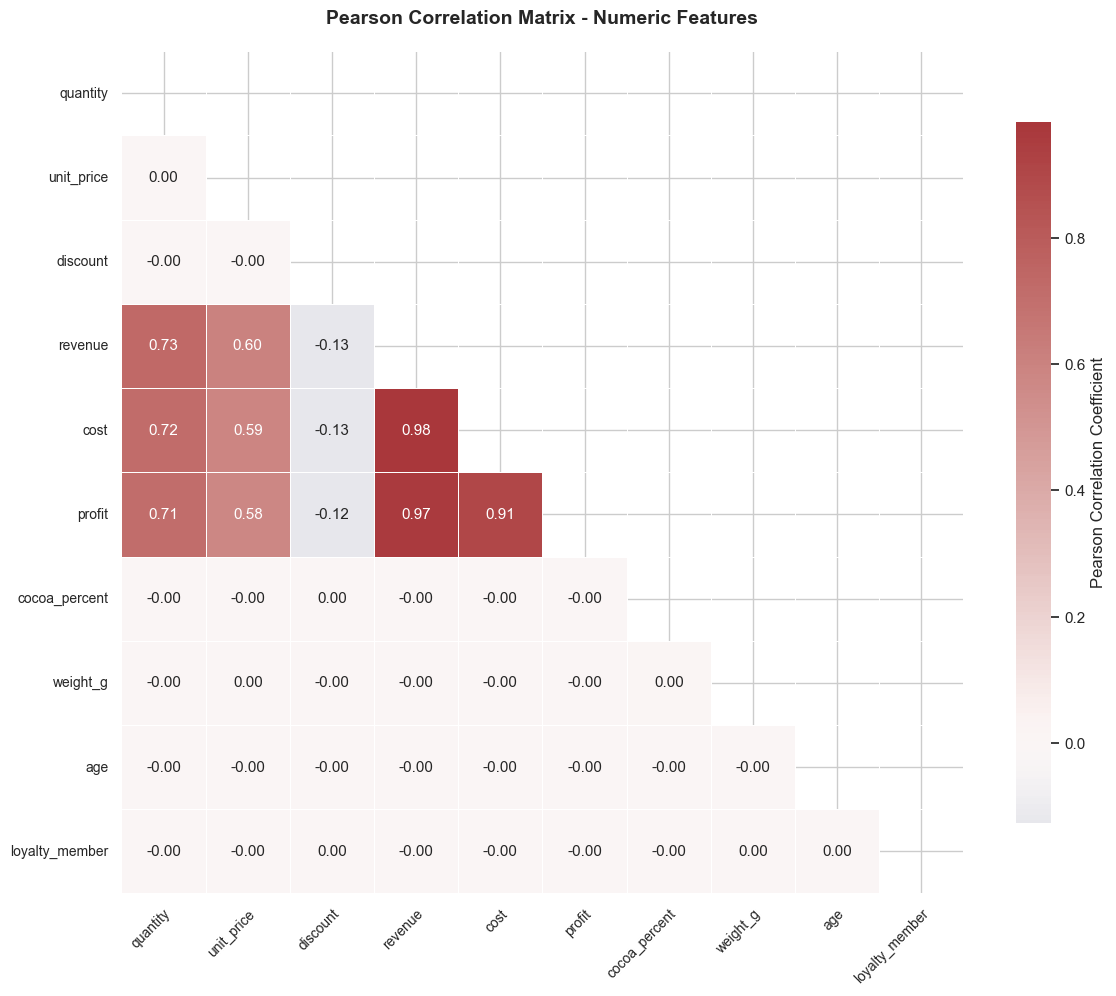

In [44]:
num_df = df.select_dtypes(include="number")
pearson_corr = num_df.corr(method="pearson")
# spearman_corr = num_df.corr(method="spearman")  # Commented out to hide Spearman matrix


def corr_pairs_long(corr: pd.DataFrame):
    cols = corr.columns
    rows = []
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            r = corr.iloc[i, j]
            rows.append((cols[i], cols[j], r))
    return pd.DataFrame(rows, columns=["a", "b", "r"]).assign(abs_r=lambda d: d["r"].abs())


pair_pearson = corr_pairs_long(pearson_corr).sort_values("abs_r", ascending=False)
# pair_spearman = corr_pairs_long(spearman_corr).sort_values("abs_r", ascending=False)  # Commented out to hide Spearman pairs

print("Top 20 Pearson pairs by |r|:\n", pair_pearson.head(20).to_string(index=False))
# print("\nTop 20 Spearman pairs by |r|:\n", pair_spearman.head(20).to_string(index=False))  # Commented out to hide Spearman output

mask = np.triu(np.ones_like(pearson_corr, dtype=bool))
heat_kw = dict(
    mask=mask,
    cmap="vlag",
    center=0,
    square=True,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 11, "ha": "center", "va": "center"},
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"shrink": 0.82, "label": "Pearson Correlation Coefficient"},
)

# Only show Pearson correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(pearson_corr, ax=ax, **heat_kw)
ax.set_title("Pearson Correlation Matrix - Numeric Features", fontsize=14, fontweight="bold", pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
fig.tight_layout()
plt.show()



## The stronger correlations in the data: **|r| > 0.1** (Pearson)

Scatter plots with regression lines for all variable pairs with absolute Pearson correlation above 0.1, sorted by strength.

Pairs with |r| > 0.1 (Pearson): 12

All Moderate Correlations (|r| > 0.1) - Sorted by Strength:

         a       b         r    abs_r
   revenue    cost  0.984524 0.984524
   revenue  profit  0.966194 0.966194
      cost  profit  0.906058 0.906058
  quantity revenue  0.733963 0.733963
  quantity    cost  0.722682 0.722682
  quantity  profit  0.709035 0.709035
unit_price revenue  0.599265 0.599265
unit_price    cost  0.590006 0.590006
unit_price  profit  0.578984 0.578984
  discount revenue -0.127325 0.127325
  discount    cost -0.125151 0.125151
  discount  profit -0.123319 0.123319


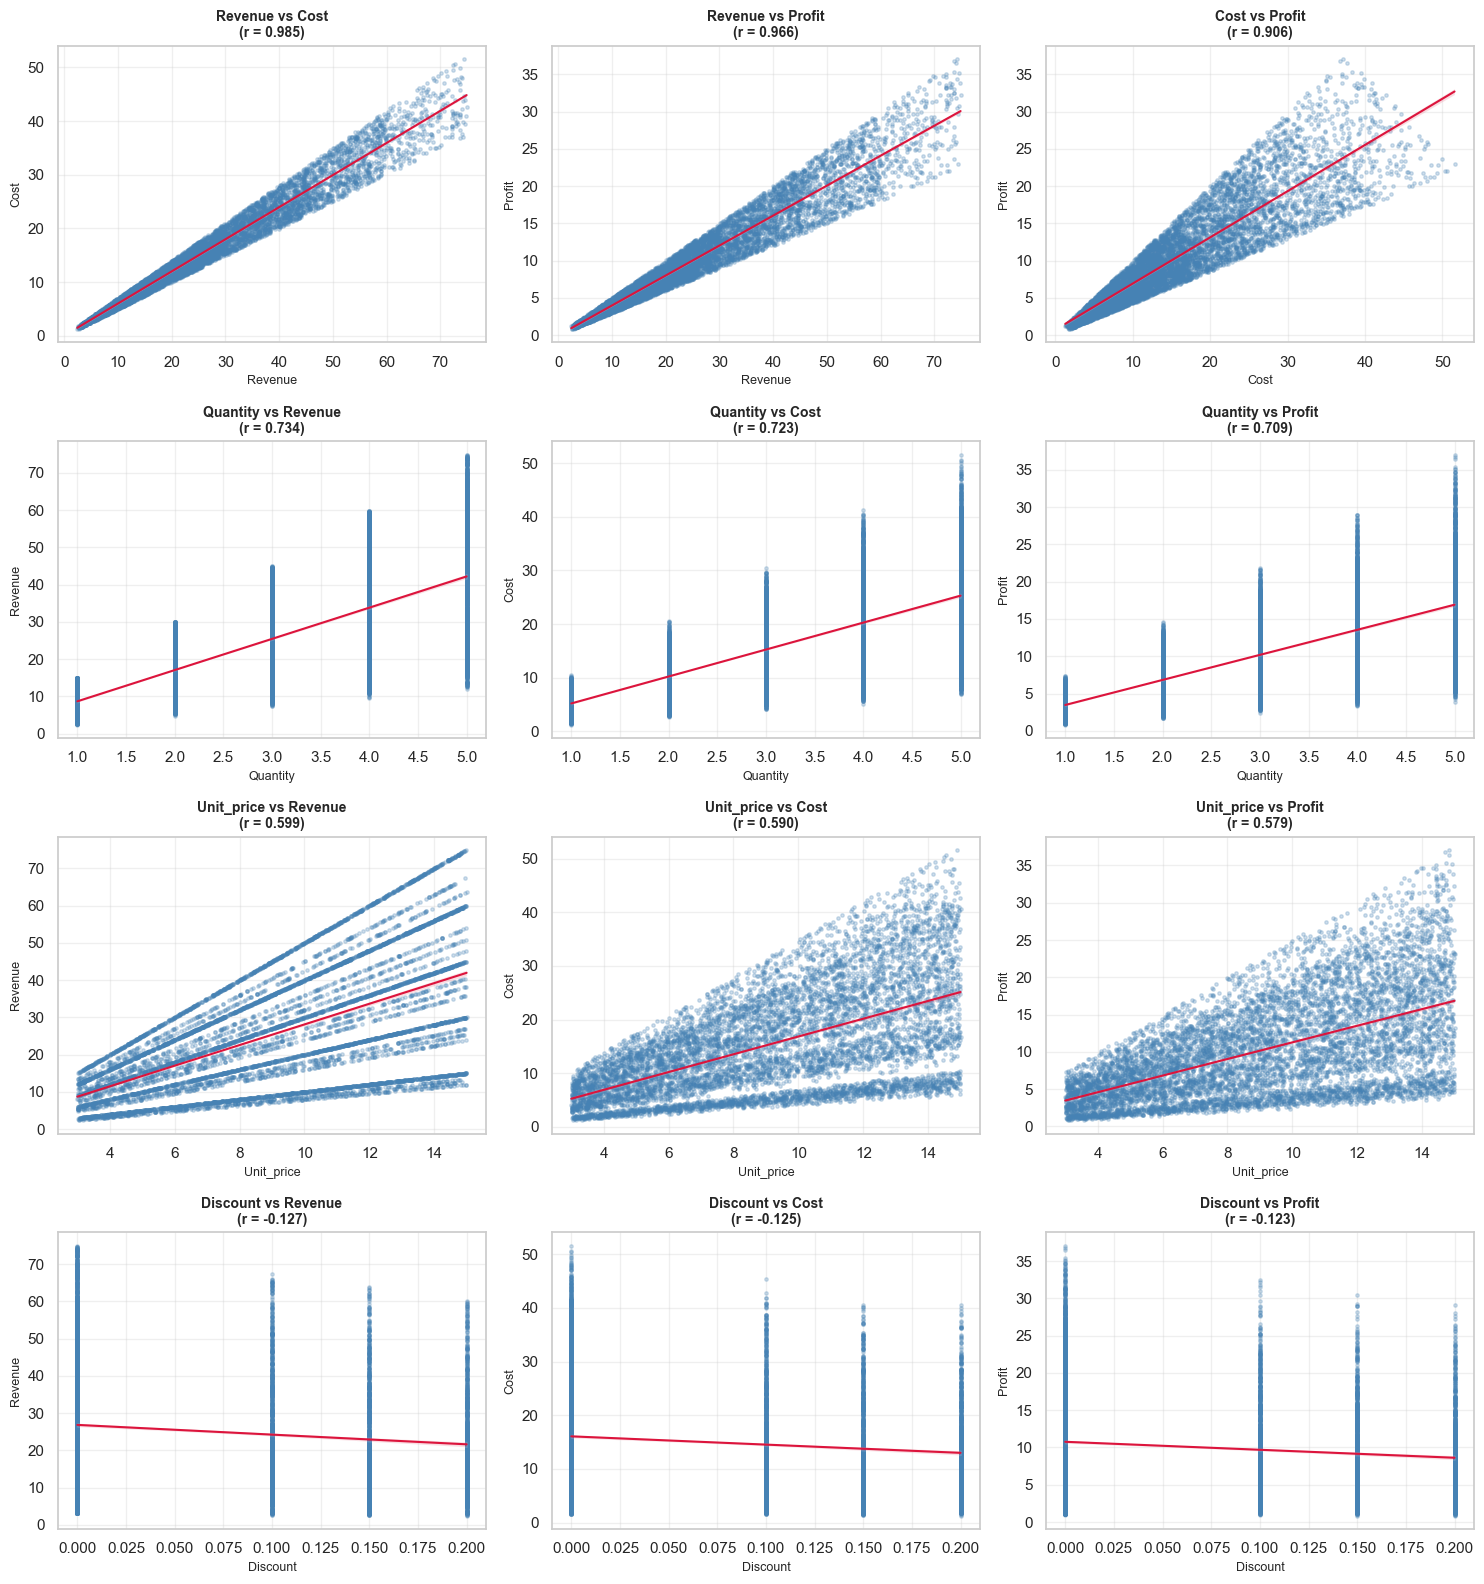

In [45]:
THRESH_MODERATE = 0.1
moderate_pairs = pair_pearson[pair_pearson["abs_r"] > THRESH_MODERATE].copy()
print(f"Pairs with |r| > {THRESH_MODERATE} (Pearson): {len(moderate_pairs)}")
print("\nAll Moderate Correlations (|r| > 0.1) - Sorted by Strength:\n")
print(moderate_pairs.to_string(index=False))

plot_sample = df.sample(n=min(8_000, len(df)), random_state=42)

if moderate_pairs.empty:
    print("No variable pairs exceed the threshold of 0.1.")
else:
    n = len(moderate_pairs)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
    axes = np.atleast_1d(axes).ravel()
    
    for ax, row in zip(axes, moderate_pairs.itertuples(index=False)):
        sns.regplot(
            data=plot_sample,
            x=row.a,
            y=row.b,
            ax=ax,
            scatter_kws={"s": 6, "alpha": 0.25, "color": "steelblue"},
            line_kws={"color": "crimson", "linewidth": 1.5},
        )
        ax.set_title(f"{row.a.capitalize()} vs {row.b.capitalize()}\n(r = {row.r:.3f})", fontsize=10, fontweight="bold")
        ax.set_xlabel(row.a.capitalize(), fontsize=9)
        ax.set_ylabel(row.b.capitalize(), fontsize=9)
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for k in range(n, len(axes)):
        axes[k].set_axis_off()
    
    plt.tight_layout()
    plt.show()

## Time series and categorical bivariate views

**Target for this story:** `revenue` (and `profit`) per line item. Daily aggregates show seasonality; boxplots compare revenue across product `category` and `country` (sampled for rendering).

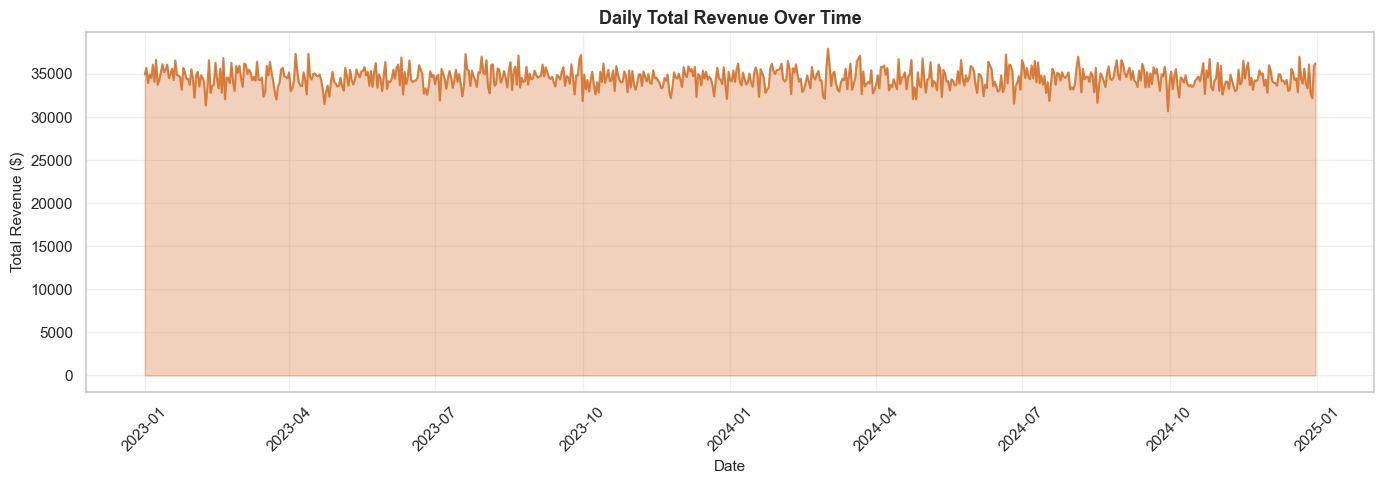

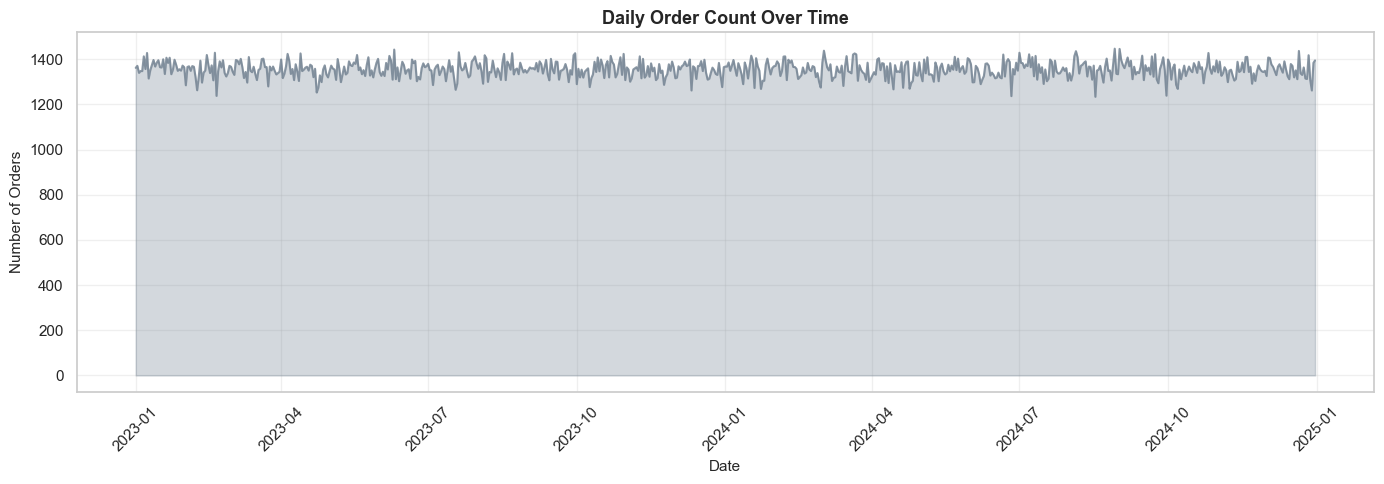

C:\Users\Yonatan\AppData\Local\Temp\ipykernel_13172\1497221973.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample_box, x="category", y="revenue", ax=axes[0], palette="Set2", width=0.7)
C:\Users\Yonatan\AppData\Local\Temp\ipykernel_13172\1497221973.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample_box, x="country", y="revenue", ax=axes[1], palette="Set3", width=0.7)


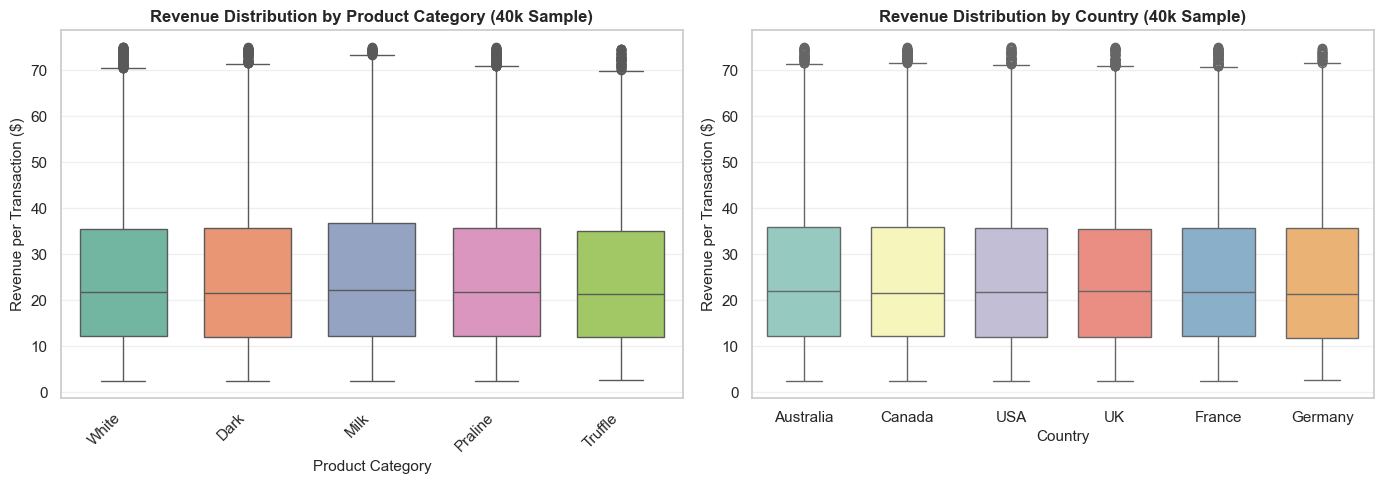

In [46]:
daily = (
    df.groupby("order_date", as_index=False)
    .agg(revenue_sum=("revenue", "sum"), profit_sum=("profit", "sum"), orders=("order_id", "count"))
    .sort_values("order_date")
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily["order_date"], daily["revenue_sum"], color="chocolate", linewidth=1.5, alpha=0.8)
ax.fill_between(daily["order_date"], daily["revenue_sum"], alpha=0.3, color="chocolate")
ax.set_title("Daily Total Revenue Over Time", fontsize=13, fontweight="bold")
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Total Revenue ($)", fontsize=11)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily["order_date"], daily["orders"], color="slategray", linewidth=1.5, alpha=0.8)
ax.fill_between(daily["order_date"], daily["orders"], alpha=0.3, color="slategray")
ax.set_title("Daily Order Count Over Time", fontsize=13, fontweight="bold")
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Number of Orders", fontsize=11)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

sample_box = df.sample(n=min(40_000, len(df)), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=sample_box, x="category", y="revenue", ax=axes[0], palette="Set2", width=0.7)
axes[0].set_title("Revenue Distribution by Product Category (40k Sample)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Product Category", fontsize=11)
axes[0].set_ylabel("Revenue per Transaction ($)", fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

sns.boxplot(data=sample_box, x="country", y="revenue", ax=axes[1], palette="Set3", width=0.7)
axes[1].set_title("Revenue Distribution by Country (40k Sample)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Country", fontsize=11)
axes[1].set_ylabel("Revenue per Transaction ($)", fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

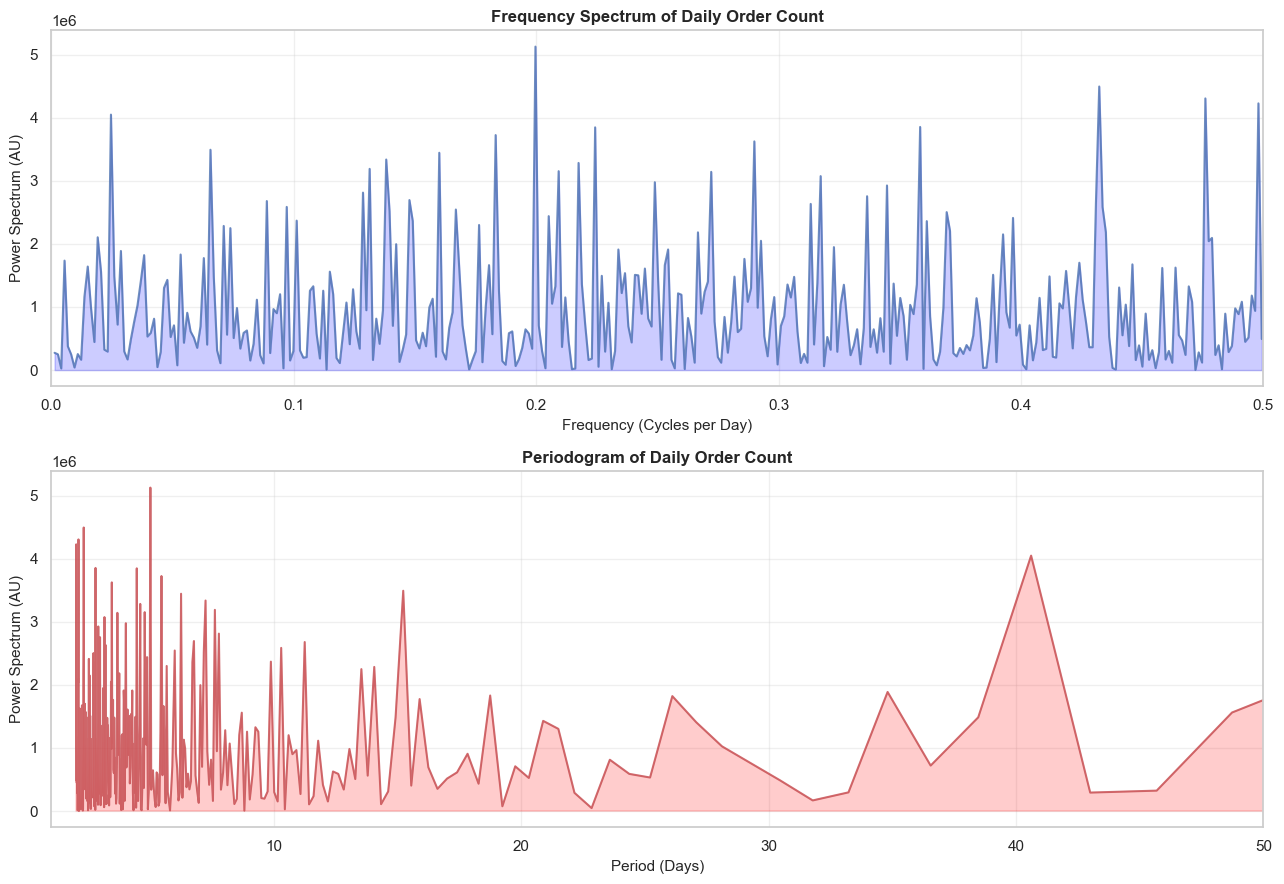

In [62]:
# Prepare data for FFT analysis
order_counts = daily["orders"].values
n = len(order_counts)

# Apply FFT to get frequency components
fft_values = np.fft.fft(order_counts)
frequencies = np.fft.fftfreq(n)

# Calculate power spectrum (magnitude squared)
power_spectrum = np.abs(fft_values) ** 2

# Only consider positive frequencies (excluding DC component)
positive_freq_idx = frequencies > 0
positive_frequencies = frequencies[positive_freq_idx]
positive_power = power_spectrum[positive_freq_idx]

# Convert frequency to period (days)
periods = 1 / positive_frequencies

# Create frequency spectrum plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9))

# Plot 1: Power Spectrum vs Frequency
ax1.plot(positive_frequencies, positive_power, 'b-', linewidth=1.5, alpha=0.8)
ax1.set_xlabel('Frequency (Cycles per Day)', fontsize=11)
ax1.set_ylabel('Power Spectrum (AU)', fontsize=11)
ax1.set_title('Frequency Spectrum of Daily Order Count', fontsize=12, fontweight="bold")
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 0.5)  # Show up to Nyquist frequency
ax1.fill_between(positive_frequencies, positive_power, alpha=0.2, color='blue')

# Plot 2: Power Spectrum vs Period (more intuitive)
ax2.plot(periods, positive_power, 'r-', linewidth=1.5, alpha=0.8)
ax2.set_xlabel('Period (Days)', fontsize=11)
ax2.set_ylabel('Power Spectrum (AU)', fontsize=11)
ax2.set_title('Periodogram of Daily Order Count', fontsize=12, fontweight="bold")
ax2.grid(True, alpha=0.3)
ax2.set_xlim(1, 50)  # Show periods from 1 day to 15 days
ax2.fill_between(periods, positive_power, alpha=0.2, color='red')

plt.tight_layout()
plt.show()

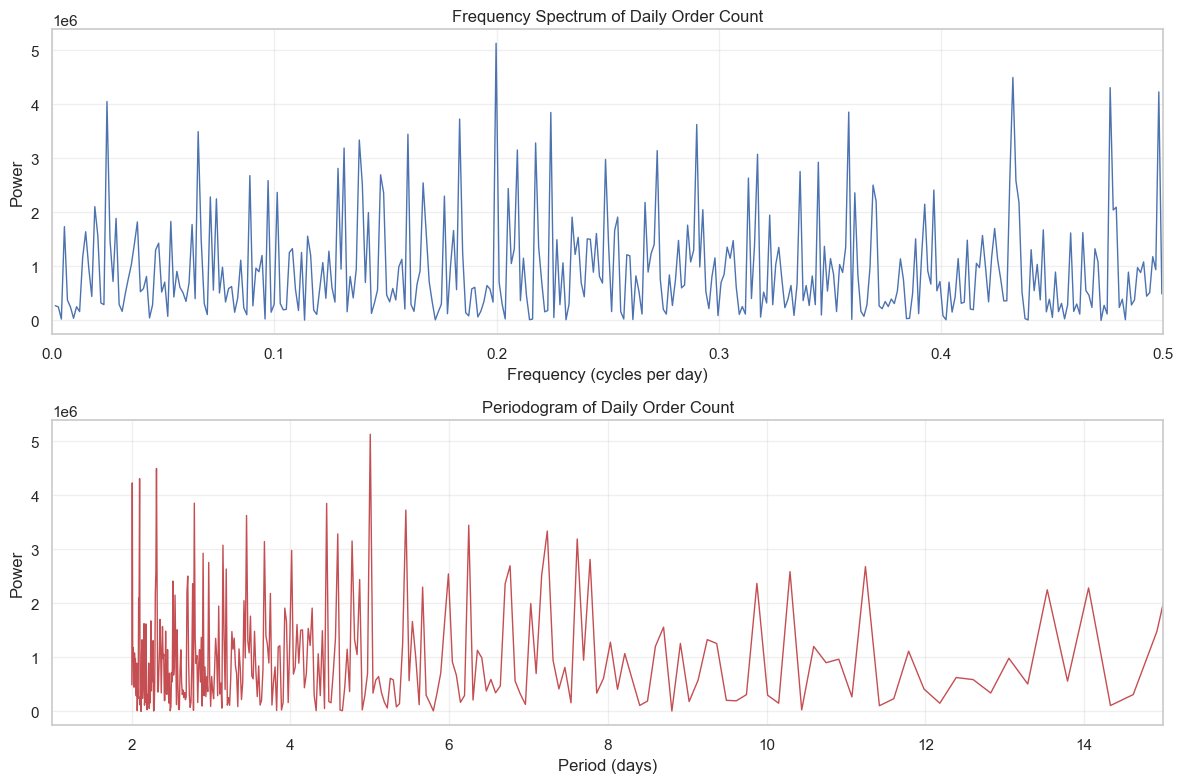

In [63]:
# Prepare data for FFT analysis
order_counts = daily["orders"].values
n = len(order_counts)

# Apply FFT to get frequency components
fft_values = np.fft.fft(order_counts)
frequencies = np.fft.fftfreq(n)

# Calculate power spectrum (magnitude squared)
power_spectrum = np.abs(fft_values) ** 2

# Only consider positive frequencies (excluding DC component)
positive_freq_idx = frequencies > 0
positive_frequencies = frequencies[positive_freq_idx]
positive_power = power_spectrum[positive_freq_idx]

# Convert frequency to period (days)
periods = 1 / positive_frequencies

# Create frequency spectrum plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: Power Spectrum vs Frequency
ax1.plot(positive_frequencies, positive_power, 'b-', linewidth=1)
ax1.set_xlabel('Frequency (cycles per day)')
ax1.set_ylabel('Power')
ax1.set_title('Frequency Spectrum of Daily Order Count')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 0.5)  # Show up to Nyquist frequency

# Plot 2: Power Spectrum vs Period (more intuitive)
ax2.plot(periods, positive_power, 'r-', linewidth=1)
ax2.set_xlabel('Period (days)')
ax2.set_ylabel('Power')
ax2.set_title('Periodogram of Daily Order Count')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(1, 15)  # Show periods from 1 day to 1 year
# ax2.set_xscale('log')  # Log scale for better visualization of different periods



plt.tight_layout()
plt.show()

Top 20 Dominant Periods in Order Count:
 1. Period:    5.0 days | Power: 5127668.1 | ~5.0 days (weekly pattern)
 2. Period:    2.3 days | Power: 4495285.7 | ~2.3 days (weekly pattern)
 3. Period:    2.1 days | Power: 4306509.2 | ~2.1 days (weekly pattern)
 4. Period:    2.0 days | Power: 4228092.0 | ~2.0 days (weekly pattern)
 5. Period:   40.6 days | Power: 4049488.6 | ~40.6 days (monthly pattern)
 6. Period:    2.8 days | Power: 3854220.5 | ~2.8 days (weekly pattern)
 7. Period:    4.5 days | Power: 3847863.2 | ~4.5 days (weekly pattern)
 8. Period:    5.5 days | Power: 3725592.7 | ~5.5 days (weekly pattern)
 9. Period:    3.4 days | Power: 3625313.9 | ~3.4 days (weekly pattern)
10. Period:   15.2 days | Power: 3492750.8 | ~15.2 days (semi-monthly pattern)
11. Period:    6.2 days | Power: 3445177.1 | ~6.2 days (weekly pattern)
12. Period:    7.2 days | Power: 3337800.5 | ~7.2 days (weekly pattern)
13. Period:    4.6 days | Power: 3283798.6 | ~4.6 days (weekly pattern)
14. Period:    

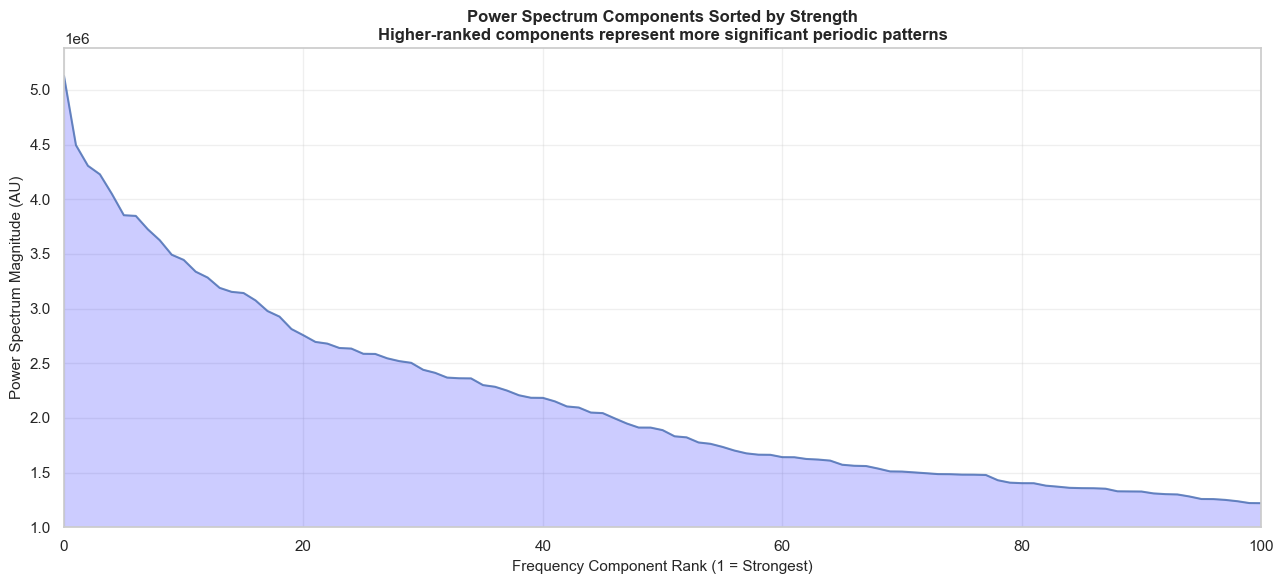

In [64]:
# Identify dominant frequencies and their interpretations
dominant_indices = np.argsort(positive_power)[-20:][::-1]  # Top 15 dominant frequencies, sorted strongest first
dominant_periods = periods[dominant_indices]
dominant_powers = positive_power[dominant_indices]

print("Top 20 Dominant Periods in Order Count:")
print("=" * 50)
for i, (period, power) in enumerate(zip(dominant_periods, dominant_powers), 1):
    if period < 2:
        interpretation = "~1 day (daily pattern)"
    elif 2 <= period < 8:
        interpretation = f"~{period:.1f} days (weekly pattern)"
    elif 8 <= period < 15:
        interpretation = f"~{period:.1f} days (bi-weekly pattern)"
    elif 15 <= period < 25:
        interpretation = f"~{period:.1f} days (semi-monthly pattern)"
    elif 25 <= period < 41:
        interpretation = f"~{period:.1f} days (monthly pattern)"
    elif 41 <= period < 70:
        interpretation = f"~{period:.1f} days (quarterly pattern)"
    elif period >= 70:
        interpretation = f"~{period:.1f} days (seasonal/annual pattern)"
    else:
        interpretation = f"~{period:.1f} days"
    
    print(f"{i:2d}. Period: {period:6.1f} days | Power: {power:8.1f} | {interpretation}")

# Find most significant periodic patterns
print("\n" + "=" * 50)
print("KEY FINDINGS:")
print("=" * 50)

# Weekly pattern (around 7 days)
weekly_mask = (periods >= 6) & (periods <= 8)
if np.any(weekly_mask):
    weekly_power = positive_power[weekly_mask].max()
    weekly_period = periods[weekly_mask][np.argmax(positive_power[weekly_mask])]
    print(f"✓ Strong weekly pattern detected: {weekly_period:.1f}-day cycle")

# Monthly pattern (around 30 days)
monthly_mask = (periods >= 28) & (periods <= 32)
if np.any(monthly_mask):
    monthly_power = positive_power[monthly_mask].max()
    monthly_period = periods[monthly_mask][np.argmax(positive_power[monthly_mask])]
    print(f"✓ Monthly pattern detected: {monthly_period:.1f}-day cycle")

# Quarterly pattern (around 90 days)
quarterly_mask = (periods >= 85) & (periods <= 95)
if np.any(quarterly_mask):
    quarterly_power = positive_power[quarterly_mask].max()
    quarterly_period = periods[quarterly_mask][np.argmax(positive_power[quarterly_mask])]
    print(f"✓ Quarterly pattern detected: {quarterly_period:.1f}-day cycle")

# Plot power values sorted by magnitude to visualize significance
plt.figure(figsize=(13, 6))
sorted_power = np.sort(positive_power)[::-1]  # Sort power values in descending order
plt.plot(sorted_power, 'b-', linewidth=1.5, alpha=0.8)
plt.fill_between(range(len(sorted_power)), sorted_power, alpha=0.2, color='blue')
plt.xlabel('Frequency Component Rank (1 = Strongest)', fontsize=11)
plt.ylabel('Power Spectrum Magnitude (AU)', fontsize=11)
plt.title('Power Spectrum Components Sorted by Strength\nHigher-ranked components represent more significant periodic patterns', 
          fontsize=12, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.ylim(bottom=1e6)  # Set minimum y-axis
plt.xlim(0, 100)  # Show only first 100 ranks
plt.tight_layout()
plt.show()

## Feature Engineering

Three new numeric features derived from string / date columns:

1. **`customer_tenure`** — days between `join_date` and `order_date`; captures how long a customer had been a member at the time of purchase.
2. **Target (mean-revenue) encoding** — each categorical ID / label is replaced with the mean transaction revenue for that group. Meaningful numeric signal; computed on the full dataset (no modelling, so no leakage concern here).
3. **Frequency (count) encoding** — each group is replaced with its transaction count. Intentionally kept alongside target encoding: the same categorical can carry different information when viewed as *volume* vs *value*.

In [65]:
# ── 1. customer_tenure ────────────────────────────────────────────────────────
df["join_date_dt"] = pd.to_datetime(df["join_date"])
df["customer_tenure"] = (df["order_date"] - df["join_date_dt"]).dt.days
df.drop(columns="join_date_dt", inplace=True)

# ── 2. Target encoding (mean revenue per group) ────────────────────────────────
target_encode_cols = ["store_id", "product_id", "city", "customer_id"]
for col in target_encode_cols:
    means = df.groupby(col)["revenue"].transform("mean")
    df[f"{col}_mean_revenue"] = means

# ── 3. Frequency encoding (transaction count per group) ───────────────────────
freq_encode_cols = ["store_id", "product_id", "customer_id"]
for col in freq_encode_cols:
    counts = df.groupby(col)["order_id"].transform("count")
    df[f"{col}_txn_count"] = counts

# ── Quick summary ──────────────────────────────────────────────────────────────
new_cols = (
    ["customer_tenure"]
    + [f"{c}_mean_revenue" for c in target_encode_cols]
    + [f"{c}_txn_count" for c in freq_encode_cols]
)
print("New feature columns:", new_cols)
print()
print(df[new_cols].describe().round(2).to_string())


New feature columns: ['customer_tenure', 'store_id_mean_revenue', 'product_id_mean_revenue', 'city_mean_revenue', 'customer_id_mean_revenue', 'store_id_txn_count', 'product_id_txn_count', 'customer_id_txn_count']

       customer_tenure  store_id_mean_revenue  product_id_mean_revenue  city_mean_revenue  customer_id_mean_revenue  store_id_txn_count  product_id_txn_count  customer_id_txn_count
count        990236.00              990236.00                990236.00          990236.00                 990236.00           990236.00             990236.00              990236.00
mean            116.50                  25.49                    25.49              25.49                     25.49             9903.19               4952.16                  20.79
std             569.27                   0.16                     0.23               0.05                      3.67               90.78                 69.55                   4.42
min           -1160.00                  24.90                 

Pearson r vs revenue (new features):

customer_id_mean_revenue    0.2240
product_id_mean_revenue     0.0141
store_id_mean_revenue       0.0097
city_mean_revenue           0.0029
product_id_txn_count       -0.0013
store_id_txn_count         -0.0012
customer_tenure             0.0008
customer_id_txn_count      -0.0006


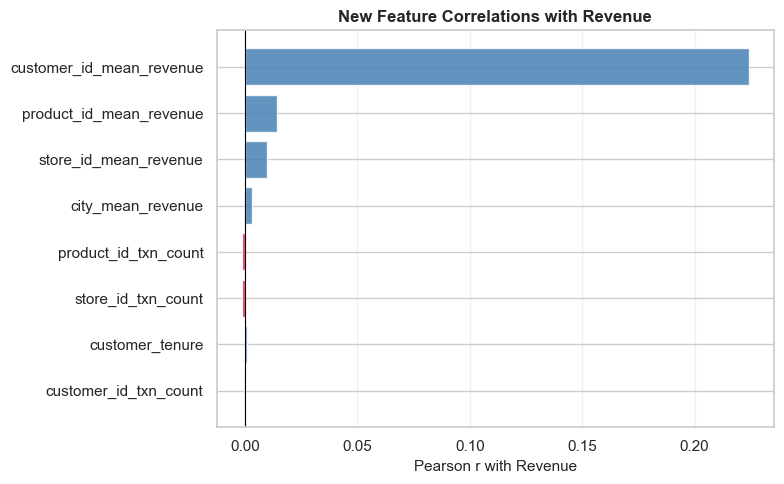

In [66]:
# Pearson correlation of new features vs revenue
corr_new = (
    df[new_cols + ["revenue"]]
    .corr(method="pearson")["revenue"]
    .drop("revenue")
    .sort_values(key=abs, ascending=False)
)
print("Pearson r vs revenue (new features):\n")
print(corr_new.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["steelblue" if v >= 0 else "crimson" for v in corr_new]
ax.barh(corr_new.index[::-1], corr_new.values[::-1], color=colors[::-1], edgecolor="white", alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson r with Revenue", fontsize=11)
ax.set_title("New Feature Correlations with Revenue", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()
